<a href="https://colab.research.google.com/github/mardycow/edtech-agent-assist/blob/main/lora_fine_tuning.ipynb" target="_parent"><img src="https://colab.research.google.com/assets/colab-badge.svg" alt="Open In Colab"/></a>

# **fine-tuning Qwen3 with LoRA**

**Установка необходимых библиотек**

In [ ]:
!pip install transformers datasets evaluate rouge-score razdel bert-score torch accelerate peft bitsandbytes trl

  Preparing metadata (setup.py) ... done
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 84.1/84.1 kB 9.6 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 61.1/61.1 kB 5.9 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 60.7/60.7 MB 45.0 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 721.6/721.6 kB 60.7 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 529.0/529.0 kB 52.4 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 48.9/48.9 MB 56.7 MB/s eta 0:00:00
  Created wheel for rouge-score: filename=rouge_score-0.1.2-py3-none-any.whl size=24934 sha256=63524e5f777a1515809787dd5d9fa7ce8b8e59690ae356adedbaea27e46b978a
  Stored in directory: /root/.cache/pip/wheels/85/9d/af/01feefbe7d55ef5468796f0c68225b6788e85d9d0a281e7a70
Successfully built rouge-score
  Attempting uninstall: pyarrow
    Found existing installation: pyarrow 18.1.0
    Uninstalling pyarrow-18.1.0:
      Successfully uninstalled pyarrow-18.1.0
  Attempting uninstall: da

In [ ]:
!pip install --upgrade torchao

   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 3.2/3.2 MB 122.4 MB/s eta 0:00:00
  Attempting uninstall: torchao
    Found existing installation: torchao 0.10.0
    Uninstalling torchao-0.10.0:
      Successfully uninstalled torchao-0.10.0


**И загрузка**

In [ ]:
import evaluate
import razdel
import pandas as pd
import numpy as np
import gc
import torch
import matplotlib.pyplot as plt
from tqdm import tqdm
from datasets import load_dataset
from transformers import AutoModelForCausalLM, AutoTokenizer
from peft import PeftModel, LoraConfig, get_peft_model
from trl import SFTConfig, SFTTrainer

In [ ]:
import os
os.environ["PYTORCH_ALLOC_CONF"] = "expandable_segments:True"
from google.colab import drive
drive.mount('/content/drive')
os.listdir()

Mounted at /content/drive


['.config', 'drive', 'sample_data']

In [ ]:
save_path = "/content/drive/MyDrive/fine tuning"

## **1. Формализация задачи**

### **Постановка**

**Задача:** абстрактивная суммаризация текста - генерация заголовков для статей СМИ на русском языке.

**Цель:** обучить модель преобразовывать полный текст статьи в лаконичный, информативный заголовок, соответствующий публицистическому стилю русского языка.

_ПРИМЕЧАНИЕ:
Дообучение необходимо для настройки стилистического единства и обеспечения чистоты генерации.
В ходе эксперимента оценивается способность моделей адаптирвоаться под задачу, сохраняя устойчивость к потере базовых навыков языка.
Основной упор сделан на проверку того, не начнет ли модель совершать ошибки в погоне за новым стилем и какая архитектура лучше держит баланс между обучением и сохранением качества текста._



### **Описание набора данных**

**Источник:** Датасет `IlyaGusev/gazeta` с платформы Hugging Face - https://huggingface.co/datasets/IlyaGusev/gazeta.

**Размер:**
- train: ~61 000 примеров;
- validation: ~6 000 примеров;
- test: ~6 000 примеров.

**Структура:**

`text` (string) - полный текст статьи (Вход X);

`title` (string) - заголовок статьи (Выход Y);

`summary` (string) - краткое содержание статьи;

`data` (string) - дата публикации статьи;

`url` (string) - ссылка на статью.

**Примеры входных и выходных данных:**

```
{
  'text': 'На официальном сайте мессенджера WhatsApp появилось сообщение о том, что с 1 февраля 2020 года сервис прекратит свою работу на некоторых устаревших смартфонах. Речь идет об устройствах, работающих на базе операционных систем Android 2.3.7 и iOS 8. При этом руководство WhatsApp предупреждает, что даже до обозначенного выше дедлайна функционал мессенджера на этих ОС может быть ограничен. «В связи с тем, что мы не планируем обновлять данные операционные системы, некоторые функции могут перестать работать на них в любое время», — говорится в пресс-релизе компании. Чтобы сохранить возможность пользоваться мессенджером без проблем, следует обновить версию прошивки или приобрести новое, более современное устройство. Сообщается, что на старых версиях операционных систем уже не получится завести новый аккаунт WhatsApp или верифицировать уже существующий. При этом в WhatsApp порекомендовали пользоваться устройствами с Android 4.0.3 и более поздними версиями, а также iOS 9 и более поздними версиями. Ранее стало известно о том, что с 31 декабря 2019 года WhatsApp прекращает поддержку устройств на базе операционной системы Windows Phone, от разработки которой пришлось отказаться. Впрочем, если верить статистике , эти меры вряд ли затронут большое количество пользователей. По состоянию на май 2019 года лишь 0,3% всех владельцев Android все еще пользуются ОС версий 2.3.3–2.3.7. Что же касается iOS, то версия под номером «10» или старше установлена на 5% устройств Apple. Как уже упоминалось выше, выпуск новых гаджетов на Windows Phone и вовсе прекращен ее создателем. В середине сентября экс-сотрудник АНБ Эдвард Сноуден раскритиковал WhatsApp за несовершенную систему защиты, порекомендовав политикам пользоваться другими средствами связи. Журналист французской радиостанции France Inter отметил, что президент Франции Эмманюэль Макрон для связи использует Telegram, а премьер-министр страны Эдуар Филипп — WhatsApp. Сноуден назвал такое решение «большой ошибкой», учитывая серьезные посты, которые занимают Макрон и Филипп. По словам Сноудена, эти сервисы безопаснее обычных SMS-сообщений, но все еще «чрезвычайно опасны, если вы премьер-министр». Больше всего претензий у информатора к WhatsApp, который стал частью активов корпорации Facebook в 2014 году. Эдвард Сноуден отметил, что после приобретения мессенджера Facebook «слой за слоем» снимает различные уровни защиты сервиса, чтобы при необходимости читать переписку своих пользователей. Ранее с критикой в адрес WhatsApp выступил и глава Telegram Павел Дуров. По словам предпринимателя, после устранения одной «дыры» в мессенджере тут же появляются новые. «Все выявленные проблемы позволяют вести слежку, выглядят и функционируют как бэкдоры», — заявил Дуров. При этом Дуров подчеркнул, что WhatsApp мог быть вынужден установить бэкдоры по указанию ФБР. В июне руководство WhatsApp заявило о том, что их сервис готов судиться с юзерами за нарушение правил пользования. В список нарушений входит использование программы «не в личных целях» и применение автоматической рассылки сообщений. По данным пресс-службы WhatsApp, уже сейчас обнаружены и заморожены «миллионы аккаунтов», пойманных на «злоупотреблении». «Наша платформа изначально создавалась, чтобы помогать людям общаться с их друзьями и любимыми... Используя информацию приложения, мы нашли и заблокировали миллионы злоупотребляющих аккаунтов от использования нашей сети», – заявили в WhatsApp. В частности, нарушение происходит, если компания публично заявляет о возможности использовать WhatsApp, нарушая при этом правила пользования мессенджером. «Ничто в этом объявлении не ограничивает право WhatsApp от применения своих условий с использованием технологий. Классификаторы на основе machine learning нам в этом помогают, и мы продолжим их использовать», – добавили в команде приложения.',
  'title': 'На последнем издыхании: у кого отключится WhatsApp'
}

```
```
{
  'text': 'Apple допустила к установке на компьютеры Mac вредоносную программу, маскирующуюся под обновление Adobe Flash Player, сообщает TechCrunch со ссылкой на ИБ-исследователя Патрика Уордла. Речь идет о вирусе под названием Shlayer. Этот троянец, попадая на компьютер жертвы, атакует ее огромным количеством рекламного программного обеспечения. Как оказалось, Apple просмотрела угрозу, исходящую от вируса. Начиная с 2019 года, все разработчики обязаны отправлять свои программы на проверку, по прохождению которой встроенная в macOS защитная система Gatekeeper позволит приложению запускаться и работать на «яблочных» компьютерах. Если же программа не проходит проверку, она моментально блокируется. Патрик Уордл утверждает, что зловред Shlayer, притворяющийся Flash Player, является первым вирусом, который смог пройти все этапы проверки от Apple. Как сообщили в пресс-службе Apple, после уведомления компании о возможной угрозе, учетная запись разработчика зловреда была заблокирована. «Вредоносное программное обеспечения постоянно меняется, поэтому система проверки Apple помогает нам не допустить зловредное ПО на Mac, а также оперативно реагировать на его обнаружение. Узнав об этом рекламном ПО, мы отозвали программу, отключили учетную запись разработчика и связанные с ним сертификаты. Мы благодарим исследователей за их помощь в обеспечении безопасности наших пользователей», — говорится в заявлении купертиновцев. По данным «Лаборатории Касперского», в прошлом году каждый восьмой пользователь macOS в России чуть не установил Shlayer на свое устройство. При этом почти треть (29%) всех атак на владельцев macOS с января по ноябрь 2019 года происходили с использованием именно этого зловреда. Исследователи «Касперского» выяснили, что чаще всего зловред пытался проникнуть на устройства с сайтов, которые реализуют схему с так называемой рекламной партнёрской программой. Кроме того, он встречался на порталах для просмотра и скачивания развлекательного контента. Также, в YouTube ссылки на зловред можно было найти в описаниях к видеороликам, а в «Википедии» – в тексте статей. «Вопреки распространенному заблуждению об абсолютной защищенности платформы macOS, злоумышленники активно атакуют ее пользователей, используя для распространения вредоносного ПО техники социальной инженерии. Угрозы таятся в том числе на крупных сайтах, внушающих доверие. На данный момент конечной целью атак троянца Shlayer на владельцев Mac в основном является агрессивный показ рекламы, но это не значит, что злоумышленники на этом и остановятся», — заявил антивирусный эксперт «Лаборатории Касперского» Антон Иванов. Однако, как показывает находка Уордла, в какой-то момент создатели Shlayer получили возможность распространять троянца на «законных» основаниях — без особых проблем пройдя официальную проверку Apple. «Apple не проверил код программы на вредоносное ПО, почему такое и смогло произойти. Но проблема была ликвидирована очень быстро за счет использования нотаризации со стороны компании. Вредоносные программы постоянно совершенствуются, поэтому нельзя сказать, что какие-то системы полностью защищены – это в принципе невозможно. Хакеры всегда идут впереди разработчиков защитного ПО, а сами разработчики вынуждены реагировать по факту создания нового вируса и по мере появления новых вредоносных программ. Все зависит только от скорости выявления проблемы, возможности ее устранения и сроков создания антивируса или защитной системы», — пояснил «Газете.Ru» партнер и директор компании «Интеллектуальный Резерв» Павел Мясоедов.',
  'title': 'Apple пропустила вредоносное ПО на компьютеры Mac'
}
```






### **Ограничения**

- **Вычислительные мощности:** использование GPU с объемом видеопамяти 40 ГБ (NVIDIA A100), что задает лимит на размер обучаемых моделей (до 14B параметров) при сохранении достаточно подходящей длины контекста для обработки текстов статей целиком.

- **Временные ограничения:** ограниченный лимит по времени из-за почасовго расхода ресурсов GPU.


## **2. Загрузка и подготовка данных**

Представленный набор данных уже разбит на обучающую, валидационную и тестовую выборки, но из-за имеющихся ограничений (влияние на скорость обучения) принято решение использовать лишь небольшое его подмножество:

`test`: 6000 примеров;

`val`: 200 примеров;

`test`: 200 примеров (для оценки и сравнения моделей до и после обучения).

In [ ]:
def format_data(examples):
  """
  Convert dataset samples to a conversational format
  """
  output_messages = []
  for text, title in zip(examples['text'], examples['title']):
      msg = [
          {"role": "system", "content": "Ты - помощник, который пишет заголовки к новостям."},
          {"role": "user", "content": f"Напиши заголовок для статьи: {text}."},
          {"role": "assistant", "content": title}
      ]
      output_messages.append(msg)
  return {"messages": output_messages}

**Загрузка train/val/test и форматирование:**

In [ ]:
dataset = load_dataset("IlyaGusev/gazeta")

train_data = dataset["train"].select(range(6000)).map(format_data, batched=True, remove_columns=dataset["train"].column_names)
val_data = dataset['validation'].select(range(200)).map(format_data, batched=True, remove_columns=dataset["validation"].column_names)
test_data = dataset["test"].select(range(200)).select_columns(["text", "title"]).to_list()

/usr/local/lib/python3.12/dist-packages/huggingface_hub/utils/_auth.py:93: UserWarning: 
The secret `HF_TOKEN` does not exist in your Colab secrets.
To authenticate with the Hugging Face Hub, create a token in your settings tab (https://huggingface.co/settings/tokens), set it as secret in your Google Colab and restart your session.
You will be able to reuse this secret in all of your notebooks.
Please note that authentication is recommended but still optional to access public models or datasets.
  warnings.warn(


README.md: 0.00B [00:00, ?B/s]

default/train/0000.parquet:   0%|          | 0.00/252M [00:00<?, ?B/s]

default/train/0001.parquet:   0%|          | 0.00/22.7M [00:00<?, ?B/s]

default/validation/0000.parquet:   0%|          | 0.00/27.8M [00:00<?, ?B/s]

...

Generating train split:   0%|          | 0/60964 [00:00<?, ? examples/s]

Generating validation split:   0%|          | 0/6369 [00:00<?, ? examples/s]

Generating test split:   0%|          | 0/6793 [00:00<?, ? examples/s]

Map:   0%|          | 0/6000 [00:00<?, ? examples/s]

Map:   0%|          | 0/200 [00:00<?, ? examples/s]

## **3. Cтратегия и описание порядка экспериментов**

Выбранная стратегия дообучения - **Прогрессия** с методом PEFT **LoRA**, что обусловлено спецификой задачи и доступными вычислительными ресурсами.

Для экспериментов выбраны модели семейства **Qwen3**:
- `Qwen3-0.6B`: маленькая модель для проверки минимального порога качества;
- `Qwen3-1.7B` и `Qwen3-4B`: потенциальный баланс скорости и точности;
- `Qwen3-8B`: для определения «потолка» качества в рамках доступных ресурсов.

Отказ от выбора Base моделей в пользу Finetuned версий позволит сосредоточиться на стилистической адаптации под специфику задачи, а не на обучении модели базовым правилам диалога с нуля.

**Порядок экспериментов:**

0. Фиксация метрик качества Baseline моделей для оценки их базовых способностей.
1. Анализ влияния гиперпараметров на качество и скорость обучения (**на модели 1.7B**)
2. Последовательное дообучение каждой из моделей **(0.6B -> 1.7B -> 4B -> 8B)**, включающее обучение адаптера для выбранной конфигурации гиперпараметров с фиксацией loss на валидационном наборе данных для предотвращения переобучения и сохранение весов адаптеров.
3. Фиксация метрик качества на тестовом наборе данных после обучения.
4. Анализ результатов всех трех моделей на основе кривой "цена-качество" и выбор финальной модели, оптимальной для использования.


## **4. Метрики качества и цены**

Для оценки эффективности прогрессии будут использованы два типа показателей:

**Метрики качества:**
- **ROUGE-1 и ROUGE-2:** оценка попадания в ключевые слова;
- **ROUGE-L:** показатель для оценки, насколько структура и порядок слов в заголовке модели совпадают с эталоном;
- **BERTScore:** смысловое соответствие эталону.

**Метрика цены:**

- **Размер базовой модели:** общее количество параметров обучаемой модели.

Для построения итоговой кривой «цена-качество» в качестве результирующего показателя используется BERTScore. Данная метрика выбрана как приоритетная, так как она наиболее точно оценивает адекватность заголовка и его логическую связь с текстом, не штрафуя модель за использование синонимов или перефразирование.

Комплексный анализ всех метрик качества позволит провести многофакторную проверку надежности модели и убедиться в отсутствии галлюцинаций.

**Реализуем функции для расчета заявленных метрик и для общей оценки модели**

In [ ]:
def compute_metrics(refs, hyps):
  """
  Compute ROUGE and BERTScore for the generated titles
  """
  rouge_metric = evaluate.load("rouge")
  bertscore_metric = evaluate.load("bertscore")

  rouge_results = rouge_metric.compute(predictions=hyps, references=refs, tokenizer=lambda x: x.split())
  bert_results = bertscore_metric.compute(predictions=hyps, references=refs, lang="ru")

  return {
      "ROUGE-1": rouge_results['rouge1'],
      "ROUGE-2": rouge_results['rouge2'],
      "ROUGE-L": rouge_results['rougeL'],
      "BERTScore": np.mean(bert_results['f1'])
  }

def postprocess(ref, hyp, language="ru", tokenize_after=True, lower=True):
  """
  Clean and tokenize text with razdel for metric consistency
  """
  ref, hyp = ref.strip(), hyp.strip()

  if tokenize_after:
    hyp = " ".join([token.text for token in razdel.tokenize(hyp)])
    ref = " ".join([token.text for token in razdel.tokenize(ref)])
  if lower:
      hyp, ref = hyp.lower(), ref.lower()
  return ref, hyp

def evaluate_model(model, tokenizer):
  """
  Run model inference on the test dataset and trigger evaluation
  """
  model.eval()
  raw_preds, raw_refs = [], []

  for item in tqdm(test_data):
    prompt =  [
        {"role": "system", "content": "Ты - помощник, который пишет заголовки к новостям."},
        {"role": "user", "content": f"Напиши заголовок для статьи: {item['text']}."}
    ]
    inputs = tokenizer.apply_chat_template(prompt, add_generation_prompt=True, enable_thinking=False, return_tensors='pt').to(model.device)

    with torch.no_grad():
        outputs = model.generate(
            **inputs,
            max_new_tokens=25,
            pad_token_id=tokenizer.eos_token_id,
            repetition_penalty=1.2,
            do_sample=False
        )

    input_len = inputs.input_ids.shape[1]
    decoded = tokenizer.decode(outputs[0][input_len:], skip_special_tokens=True)

    raw_preds.append(decoded)
    raw_refs.append(item["title"])

  processed_preds, processed_refs = [], []
  for r, h in zip(raw_refs, raw_preds):
      clean_ref, clean_hyp = postprocess(r, h, language="ru", tokenize_after=True, lower=True)
      if clean_ref and clean_hyp:
          processed_refs.append(clean_ref)
          processed_preds.append(clean_hyp)

  print("\nСРАВНЕНИЕ РЕЗУЛЬТАТОВ:")
  print("-" * 60)
  for i in range(5):
    print(f"ОРИГИНАЛЬНЫЙ ЗАГОЛОВОК: {raw_refs[i]}")
    print(f"ЗАГОЛОВОК МОДЕЛИ:      {raw_preds[i]}")
    print("-" * 60)

  result = compute_metrics(processed_refs, processed_preds)

  return result

## **5. Реализация экспериментов**


**Для удобства обозначим имена моделей отдельным списком и создадим общий DataFrame для хранения метрик**

In [ ]:
MODELS = [
    "Qwen/Qwen3-0.6B",
    "Qwen/Qwen3-1.7B",
    "Qwen/Qwen3-4B",
    "Qwen/Qwen3-8B"
  ]

metrics_log = pd.DataFrame()

**Реализуем функцию для загрузки модели и токенизатора (опционально с адаптером)**

In [ ]:
def load_model_and_tokenizer(model_name, adapter_path=None, is_trainable=False, r=16):
    """
    Load model and tokenizer
    """
    model = AutoModelForCausalLM.from_pretrained(
        model_name,
        torch_dtype=torch.bfloat16,
        device_map="auto",
        trust_remote_code=True,
        attn_implementation="sdpa"
    )

    tokenizer = AutoTokenizer.from_pretrained(model_name, trust_remote_code=True)
    tokenizer.pad_token = tokenizer.eos_token

    if adapter_path:
        print(f"Загрузка адаптера из {adapter_path}...")
        model = PeftModel.from_pretrained(model, adapter_path)
    elif is_trainable:
        tokenizer.chat_template = (
            "{% for message in messages %}"
            "{{'<|im_start|>' + message['role'] + '\n'}}"
            "{% if message['role'] == 'assistant' %}"
            "{% generation %}{{ message['content'] }}{% endgeneration %}"
            "{% else %}"
            "{{ message['content'] }}"
            "{% endif %}"
            "{{ '<|im_end|>\n' }}"
            "{% endfor %}"
            "{% if add_generation_prompt %}{{ '<|im_start|>assistant\n' }}{% endif %}"
            )

        print(f"Инициализация LoRA (r={r})...")
        lora_config = LoraConfig(
            r=r, lora_alpha=r*2,
            target_modules=["q_proj", "k_proj", "v_proj", "o_proj", "gate_proj", "up_proj", "down_proj"],
            lora_dropout=0.05,
            task_type="CAUSAL_LM"
        )

        model = get_peft_model(model, lora_config)

    return model, tokenizer


**И функцию для освобождения памяти для оптимальной циклической обработки**

In [ ]:
def clean_up():
  """
  Clear system and GPU memory
  """
  gc.collect()

  torch.cuda.empty_cache()
  torch.cuda.ipc_collect()
  torch.cuda.reset_peak_memory_stats()

In [ ]:
def run_evaluation(model_names, adapter_suffix=None):
  """
  Sequentially evaluate models and update the global metrics log
  """
  global metrics_log

  for model_name in model_names:
    adapter_path = f"{save_path}/{model_name.split('/')[-1]}_{adapter_suffix}" if adapter_suffix else None

    status = "Finetuned" if adapter_suffix else "Baseline"

    model, tokenizer = load_model_and_tokenizer(model_name, adapter_path=adapter_path)
    metrics = evaluate_model(model, tokenizer)

    new_row = {
        "model": f"{model_name} ({status})",
        **metrics
        }

    metrics_log = pd.concat([metrics_log, pd.DataFrame([new_row])], ignore_index=True)

    del model, tokenizer
    clean_up()

  print(f"ТЕКУЩИЕ РЕЗУЛЬТАТЫ:")
  display(metrics_log)

### **Оценка Baseline моделей**

In [ ]:
run_evaluation(MODELS)

Loading weights:   0%|          | 0/311 [00:00<?, ?it/s]

The tied weights mapping and config for this model specifies to tie model.embed_tokens.weight to lm_head.weight, but both are present in the checkpoints, so we will NOT tie them. You should update the config with `tie_word_embeddings=False` to silence this warning
100%|██████████| 200/200 [03:37<00:00,  1.09s/it]



СРАВНЕНИЕ РЕЗУЛЬТАТОВ:
------------------------------------------------------------
ОРИГИНАЛЬНЫЙ ЗАГОЛОВОК: В Германии объяснили упоминание имени Путина на протестах в Берлине 
ЗАГОЛОВОК МОДЕЛИ:      **Протест в Берлине: Активисты обозначают ценность российского
------------------------------------------------------------
ОРИГИНАЛЬНЫЙ ЗАГОЛОВОК: Делегации Израиля и США прибыли в ОАЭ для обсуждения соглашения о сотрудничестве 
ЗАГОЛОВОК МОДЕЛИ:      **Высокопоставленная американская и израильская делегация находятся в ОА
------------------------------------------------------------
ОРИГИНАЛЬНЫЙ ЗАГОЛОВОК: Оппозиция Белоруссии объявила о создании новой партии «Вместе» 
ЗАГОЛОВОК МОДЕЛИ:      **«Опозиционная политическая инновация Беларуси: Уже создано «Вмест
------------------------------------------------------------
ОРИГИНАЛЬНЫЙ ЗАГОЛОВОК: Россия считает крайне опасными действия США на учениях в Эстонии 
ЗАГОЛОВОК МОДЕЛИ:      **ВОЕННЫЕ УЧЕНИЯ В ЭСТЕНОИЙ ТРЕБУЮЩИ
----------------------

config.json:   0%|          | 0.00/625 [00:00<?, ?B/s]

tokenizer_config.json:   0%|          | 0.00/49.0 [00:00<?, ?B/s]

...


СРАВНЕНИЕ РЕЗУЛЬТАТОВ:
------------------------------------------------------------
ОРИГИНАЛЬНЫЙ ЗАГОЛОВОК: В Германии объяснили упоминание имени Путина на протестах в Берлине 
ЗАГОЛОВОК МОДЕЛИ:      **В Берлине прошли массовые протесты против антиковидных мер, участники скандиров
------------------------------------------------------------
ОРИГИНАЛЬНЫЙ ЗАГОЛОВОК: Делегации Израиля и США прибыли в ОАЭ для обсуждения соглашения о сотрудничестве 
ЗАГОЛОВОК МОДЕЛИ:      **"Историческое соглашение: США, Израиль и ОАЭ открывают новый этап в истории
------------------------------------------------------------
ОРИГИНАЛЬНЫЙ ЗАГОЛОВОК: Оппозиция Белоруссии объявила о создании новой партии «Вместе» 
ЗАГОЛОВОК МОДЕЛИ:      **"Оппозиция Белоруссии создаёт новую партию "Вместе": между
------------------------------------------------------------
ОРИГИНАЛЬНЫЙ ЗАГОЛОВОК: Россия считает крайне опасными действия США на учениях в Эстонии 
ЗАГОЛОВОК МОДЕЛИ:      **"Россия осудила американские учёты в Эст

Loading weights:   0%|          | 0/199 [00:00<?, ?it/s]

BertModel LOAD REPORT from: bert-base-multilingual-cased
Key                                        | Status     |  | 
-------------------------------------------+------------+--+-
cls.seq_relationship.weight                | UNEXPECTED |  | 
cls.seq_relationship.bias                  | UNEXPECTED |  | 
cls.predictions.transform.LayerNorm.bias   | UNEXPECTED |  | 
cls.predictions.transform.LayerNorm.weight | UNEXPECTED |  | 
cls.predictions.bias                       | UNEXPECTED |  | 
cls.predictions.transform.dense.weight     | UNEXPECTED |  | 
cls.predictions.transform.dense.bias       | UNEXPECTED |  | 

Notes:
- UNEXPECTED	:can be ignored when loading from different task/architecture; not ok if you expect identical arch.


ТЕКУЩИЕ РЕЗУЛЬТАТЫ:


,model,ROUGE-1,ROUGE-2,ROUGE-L,BERTScore
0,Qwen/Qwen3-0.6B (Baseline),0.133072,0.034812,0.121744,0.685931
1,Qwen/Qwen3-1.7B (Baseline),0.182268,0.058981,0.168432,0.721668
2,Qwen/Qwen3-4B (Baseline),0.198097,0.064916,0.177780,0.722546
3,Qwen/Qwen3-8B (Baseline),0.187216,0.062349,0.171195,0.723834


In [ ]:
# Отдельный вывод метрик для удобства

print(f"ТЕКУЩИЕ РЕЗУЛЬТАТЫ:")
display(metrics_log)

ТЕКУЩИЕ РЕЗУЛЬТАТЫ:


,model,ROUGE-1,ROUGE-2,ROUGE-L,BERTScore
0,Qwen/Qwen3-0.6B (Baseline),0.133072,0.034812,0.121744,0.685931
1,Qwen/Qwen3-1.7B (Baseline),0.182268,0.058981,0.168432,0.721668
2,Qwen/Qwen3-4B (Baseline),0.198097,0.064916,0.177780,0.722546
3,Qwen/Qwen3-8B (Baseline),0.187216,0.062349,0.171195,0.723834


### **Анализ влияния гиперпараметров (на примере Qwen3-1.7B)**

В рамках анализа на примере заявленной модели будем ориентироваться на динамику и финальное значение Loss на валидационной выборке.

Анализ направлен на подбор оптимального шага обучения (**Learning Rate**) и ранга адаптера (**Rank**).

Выбранные конфигурации эксперимента:
- **(LR 1e-4, R 16):** базовый вариант для моделей данного масштаба;
- **(LR 2e-4, R 16):** увеличенный шаг обучения проверяет возможность ускорения процесса без потери точности весов;
- **(LR 1e-4, R 32):** проверка необходимости дополнительных параметров для фиксации сложных стилистических особенностей текста.

Для всех тестов определим фиксированное число эпох равное **2**, чтобы выявить контрольную точку переобучения.

In [ ]:
configs = [
    {"lr": 1e-4, "r": 16},
    {"lr": 2e-4, "r": 16},
    {"lr": 1e-4, "r": 32}
]

# Для удобства возьмем ограниченное число обучающих и валидационных примеров
train_subset = train_data.shuffle(seed=42).select(range(1000))
val_subset = val_data.shuffle(seed=42).select(range(100))

def run_experiment(model_name, lr, r):
    model, tokenizer = load_model_and_tokenizer(model_name, is_trainable=True, r=r)

    sft_config = SFTConfig(
        output_dir=f"./experiment_lr{lr}_r{r}",
        max_length=4096,
        lr_scheduler_type="cosine",
        warmup_steps=0.1,
        optim="paged_adamw_32bit",
        weight_decay=0.01,
        dataset_text_field="messages",
        packing=False,
        assistant_only_loss=True,
        num_train_epochs=2,
        per_device_train_batch_size=2,
        gradient_accumulation_steps=16,
        per_device_eval_batch_size=1,
        eval_accumulation_steps=1,
        learning_rate=lr,
        bf16=True,
        gradient_checkpointing=True,
        max_grad_norm=0.3,
        eval_strategy="steps",
        eval_steps=10,
        logging_steps=1,
        report_to="none",
        save_strategy="no"
    )

    trainer = SFTTrainer(
        model=model,
        args=sft_config,
        train_dataset=train_subset,
        eval_dataset=val_subset,
        processing_class=tokenizer
    )

    train_result = trainer.train()

    final_val_loss = trainer.evaluate()['eval_loss']

    del trainer, model, tokenizer
    clean_up()

    return final_val_loss

**Запустим цикл для проверки каждой конфигурации**

In [ ]:
experiment_log = pd.DataFrame()

for cfg in configs:
  clean_up()
  v_loss = run_experiment("Qwen/Qwen3-1.7B", cfg['lr'], cfg['r'])

  res = {
      "model": f"Qwen3-1.7B",
      "LR": cfg['lr'],
      "Rank": cfg['r'],
      "Final_Val_Loss": round(v_loss, 4)
  }
  experiment_log = pd.concat([experiment_log, pd.DataFrame([res])], ignore_index=True)

print(f"РЕЗУЛЬТАТЫ ЭКСПЕРИМЕНТА:")
display(experiment_log)

config.json:   0%|          | 0.00/726 [00:00<?, ?B/s]

`torch_dtype` is deprecated! Use `dtype` instead!


model.safetensors.index.json: 0.00B [00:00, ?B/s]

Fetching 2 files:   0%|          | 0/2 [00:00<?, ?it/s]

Loading weights:   0%|          | 0/311 [00:00<?, ?it/s]

...

Инициализация LoRA (r=32)...


The tokenizer has new PAD/BOS/EOS tokens that differ from the model config and generation config. The model config and generation config were aligned accordingly, being updated with the tokenizer's values. Updated tokens: {'bos_token_id': None, 'pad_token_id': 151645}.


Step,Training Loss,Validation Loss
10,2.569986,1.923812
20,2.282898,1.852301
30,2.163882,1.876516
40,2.122329,1.899515
50,1.743358,1.898014
60,1.835391,1.900477


РЕЗУЛЬТАТЫ ЭКСПЕРИМЕНТА:


,model,LR,Rank,Final_Val_Loss
0,Qwen3-1.7B,0.0001,16,1.8412
1,Qwen3-1.7B,0.0002,16,1.9587
2,Qwen3-1.7B,0.0001,32,1.9004


Эксперимент показал, что увеличение рассматриваемых гиперпараметров не дает существенного прироста в стабильности и качестве, так как минимальный validation loss достигается на базовых параметрах, а избыточная сложность адаптеров лишь ускоряет переобучение.

К тому же, становится очевидно, что для небольшого объема данных достаточно **одной** эпохи обучения, после нее модель склонна к переобучению.

Поэтому для дообучения всех моделей будем использовать одну эпоху обучения, а выбор ранга и скорости обучения ограничим стандартными конфигурациями под каждую конкретную архитектуру, отталкиваясь от баланса между размером модели и доступными ресурсами.



### **Fine-tuning**

**Теперь немного модифицируем общую функцию, реализующую fine-tuning:**
- предусмотрим возможность передачи индивидуальной конфигурации гиперпараметров (learning rate, rank, per_device_train_batch_size, gradient_accumulation_steps) для каждой модели;
- добавим сохранение весов адаптера для каждой модели в отдельную директорию.


In [ ]:
def run_fine_tuning(model_name, lr, r, batch_size, grad_accum):
    model, tokenizer = load_model_and_tokenizer(model_name, is_trainable=True, r=r)

    sft_config = SFTConfig(
        output_dir=f"{save_path}/logs_{model_name.split('/')[-1]}",
        max_length=4096,
        lr_scheduler_type="cosine",
        warmup_ratio=0.1,
        optim="paged_adamw_32bit",
        weight_decay=0.01,
        dataset_text_field="messages",
        packing=False,
        assistant_only_loss=True,
        num_train_epochs=1,
        per_device_train_batch_size=batch_size,
        gradient_accumulation_steps=grad_accum,
        per_device_eval_batch_size=1,
        eval_accumulation_steps=1,
        learning_rate=lr,
        bf16=True,
        gradient_checkpointing=True,
        gradient_checkpointing_kwargs={"use_reentrant": False},
        max_grad_norm=0.3,
        save_total_limit=1,
        eval_strategy="steps",
        load_best_model_at_end=True,
        eval_steps=25,
        logging_steps=25,
        report_to="none",
        save_strategy="steps"
    )

    trainer = SFTTrainer(
        model=model,
        args=sft_config,
        train_dataset=train_data,
        eval_dataset=val_data,
        processing_class=tokenizer
    )

    trainer.train()

    model.save_pretrained(f"{save_path}/{model_name.split('/')[-1]}_final_adapter")
    print(f"Обучение завершено. Адаптер сохранен в {save_path}/{model_name.split('/')[-1]}_final_adapter")

    del trainer, model, tokenizer
    clean_up()

**Провдем дообучения для каждой модели последовательно для удобства корректирования гиперпараметров и контроля за вычислительными ресурсами**

#### **Qwen3-0.6B**

In [ ]:
run_fine_tuning(MODELS[0], 2e-4, 16, 4, 8)

config.json:   0%|          | 0.00/726 [00:00<?, ?B/s]

model.safetensors:   0%|          | 0.00/1.50G [00:00<?, ?B/s]

Loading weights:   0%|          | 0/311 [00:00<?, ?it/s]

The tied weights mapping and config for this model specifies to tie model.embed_tokens.weight to lm_head.weight, but both are present in the checkpoints, so we will NOT tie them. You should update the config with `tie_word_embeddings=False` to silence this warning


generation_config.json:   0%|          | 0.00/239 [00:00<?, ?B/s]

...

Tokenizing train dataset:   0%|          | 0/6000 [00:00<?, ? examples/s]

Tokenizing eval dataset:   0%|          | 0/200 [00:00<?, ? examples/s]

The tokenizer has new PAD/BOS/EOS tokens that differ from the model config and generation config. The model config and generation config were aligned accordingly, being updated with the tokenizer's values. Updated tokens: {'bos_token_id': None, 'pad_token_id': 151645}.


Step,Training Loss,Validation Loss
25,3.222697,2.251842
50,2.281518,2.228692
75,2.178754,2.233438
100,2.150542,2.225782
125,2.149820,2.158650
150,2.060926,2.163849
175,2.099193,2.169290


Обучение завершено. Адаптер сохранен в /content/drive/MyDrive/fine tuning/Qwen3-0.6B_final_adapter


#### **Qwen3-1.7B**

In [ ]:
run_fine_tuning(MODELS[1], 1e-4, 16, 2, 16)

Loading weights:   0%|          | 0/311 [00:00<?, ?it/s]

The tied weights mapping and config for this model specifies to tie model.embed_tokens.weight to lm_head.weight, but both are present in the checkpoints, so we will NOT tie them. You should update the config with `tie_word_embeddings=False` to silence this warning


Инициализация LoRA (r=16)...


warmup_ratio is deprecated and will be removed in v5.2. Use `warmup_steps` instead.


Tokenizing train dataset:   0%|          | 0/6000 [00:00<?, ? examples/s]

Tokenizing eval dataset:   0%|          | 0/200 [00:00<?, ? examples/s]

The tokenizer has new PAD/BOS/EOS tokens that differ from the model config and generation config. The model config and generation config were aligned accordingly, being updated with the tokenizer's values. Updated tokens: {'bos_token_id': None, 'pad_token_id': 151645}.


Step,Training Loss,Validation Loss
25,4.126521,1.818887
50,2.051522,1.887137
75,1.918189,1.995078
100,1.915919,1.926557
125,1.908630,1.883161
150,1.830086,1.880188
175,1.884361,1.889468


Обучение завершено. Адаптер сохранен в /content/drive/MyDrive/fine tuning/Qwen3-1.7B_final_adapter


#### **Qwen3-4B**

In [ ]:
run_fine_tuning(MODELS[2], 3e-5, 16, 1, 32)

config.json:   0%|          | 0.00/726 [00:00<?, ?B/s]

model.safetensors.index.json: 0.00B [00:00, ?B/s]

Fetching 3 files:   0%|          | 0/3 [00:00<?, ?it/s]

Loading weights:   0%|          | 0/398 [00:00<?, ?it/s]

generation_config.json:   0%|          | 0.00/239 [00:00<?, ?B/s]

...

Tokenizing train dataset:   0%|          | 0/6000 [00:00<?, ? examples/s]

Tokenizing eval dataset:   0%|          | 0/200 [00:00<?, ? examples/s]

The tokenizer has new PAD/BOS/EOS tokens that differ from the model config and generation config. The model config and generation config were aligned accordingly, being updated with the tokenizer's values. Updated tokens: {'bos_token_id': None, 'pad_token_id': 151645}.


Step,Training Loss,Validation Loss
25,4.549292,1.748518
50,2.151564,1.648533
75,1.877634,1.706541
100,1.840020,1.713963
125,1.841855,1.702436
150,1.734517,1.699974
175,1.797142,1.699186


Обучение завершено. Адаптер сохранен в /content/drive/MyDrive/fine tuning/Qwen3-4B_final_adapter


#### **Qwen3-8B**

In [ ]:
run_fine_tuning(MODELS[3], 3e-5, 16, 1, 32)

config.json:   0%|          | 0.00/728 [00:00<?, ?B/s]

model.safetensors.index.json: 0.00B [00:00, ?B/s]

Fetching 5 files:   0%|          | 0/5 [00:00<?, ?it/s]

Loading weights:   0%|          | 0/399 [00:00<?, ?it/s]

generation_config.json:   0%|          | 0.00/239 [00:00<?, ?B/s]

...

Tokenizing train dataset:   0%|          | 0/6000 [00:00<?, ? examples/s]

Tokenizing eval dataset:   0%|          | 0/200 [00:00<?, ? examples/s]

The tokenizer has new PAD/BOS/EOS tokens that differ from the model config and generation config. The model config and generation config were aligned accordingly, being updated with the tokenizer's values. Updated tokens: {'bos_token_id': None, 'pad_token_id': 151645}.


Step,Training Loss,Validation Loss
25,4.990358,1.705157
50,2.228327,1.500465
75,1.832914,1.531753
100,1.744415,1.553997
125,1.718737,1.547270
150,1.626751,1.536433
175,1.695995,1.534053


Обучение завершено. Адаптер сохранен в /content/drive/MyDrive/fine tuning/Qwen3-8B_final_adapter


### **Оценка Finetuned моделей**

In [ ]:
run_evaluation(MODELS, adapter_suffix='final_adapter')

Loading weights:   0%|          | 0/311 [00:00<?, ?it/s]

The tied weights mapping and config for this model specifies to tie model.embed_tokens.weight to lm_head.weight, but both are present in the checkpoints, so we will NOT tie them. You should update the config with `tie_word_embeddings=False` to silence this warning


Загрузка адаптера из /content/drive/MyDrive/fine tuning/Qwen3-0.6B_final_adapter...


100%|██████████| 200/200 [06:52<00:00,  2.06s/it]



СРАВНЕНИЕ РЕЗУЛЬТАТОВ:
------------------------------------------------------------
ОРИГИНАЛЬНЫЙ ЗАГОЛОВОК: В Германии объяснили упоминание имени Путина на протестах в Берлине 
ЗАГОЛОВОК МОДЕЛИ:      Протестеры обманулли Путина на выходных 29 и 30 августа 2
------------------------------------------------------------
ОРИГИНАЛЬНЫЙ ЗАГОЛОВОК: Делегации Израиля и США прибыли в ОАЭ для обсуждения соглашения о сотрудничестве 
ЗАГОЛОВОК МОДЕЛИ:      «Мир должен быть один» (ЛЯ) 13 августа 2020 года 14 сентября
------------------------------------------------------------
ОРИГИНАЛЬНЫЙ ЗАГОЛОВОК: Оппозиция Белоруссии объявила о создании новой партии «Вместе» 
ЗАГОЛОВОК МОДЕЛИ:      «Вместе» станет лидером Белоруссы 2024 годом 2025
------------------------------------------------------------
ОРИГИНАЛЬНЫЙ ЗАГОЛОВОК: Россия считает крайне опасными действия США на учениях в Эстонии 
ЗАГОЛОВОК МОДЕЛИ:      Восточный франциянский фланг США не покажется им визначенным 25 лет тому
---------------------

...


СРАВНЕНИЕ РЕЗУЛЬТАТОВ:
------------------------------------------------------------
ОРИГИНАЛЬНЫЙ ЗАГОЛОВОК: В Германии объяснили упоминание имени Путина на протестах в Берлине 
ЗАГОЛОВОК МОДЕЛИ:      Протестеры вспомнили Путина во время карантина
------------------------------------------------------------
ОРИГИНАЛЬНЫЙ ЗАГОЛОВОК: Делегации Израиля и США прибыли в ОАЭ для обсуждения соглашения о сотрудничестве 
ЗАГОЛОВОК МОДЕЛИ:      ОАЭ стали первыми союзниками Израиля после Трампа
------------------------------------------------------------
ОРИГИНАЛЬНЫЙ ЗАГОЛОВОК: Оппозиция Белоруссии объявила о создании новой партии «Вместе» 
ЗАГОЛОВОК МОДЕЛИ:      «Вместе» начинается без Лукашенко  
(по материалам сайта "Голос Америки
------------------------------------------------------------
ОРИГИНАЛЬНЫЙ ЗАГОЛОВОК: Россия считает крайне опасными действия США на учениях в Эстонии 
ЗАГОЛОВОК МОДЕЛИ:      **Маневры НАТО возле границ России вызвали ответную реакцию из Москвы**
----------------------

Loading weights:   0%|          | 0/199 [00:00<?, ?it/s]

BertModel LOAD REPORT from: bert-base-multilingual-cased
Key                                        | Status     |  | 
-------------------------------------------+------------+--+-
cls.seq_relationship.weight                | UNEXPECTED |  | 
cls.seq_relationship.bias                  | UNEXPECTED |  | 
cls.predictions.transform.LayerNorm.bias   | UNEXPECTED |  | 
cls.predictions.transform.LayerNorm.weight | UNEXPECTED |  | 
cls.predictions.bias                       | UNEXPECTED |  | 
cls.predictions.transform.dense.weight     | UNEXPECTED |  | 
cls.predictions.transform.dense.bias       | UNEXPECTED |  | 

Notes:
- UNEXPECTED	:can be ignored when loading from different task/architecture; not ok if you expect identical arch.


ТЕКУЩИЕ РЕЗУЛЬТАТЫ:


,model,ROUGE-1,ROUGE-2,ROUGE-L,BERTScore
0,Qwen/Qwen3-0.6B (Baseline),0.133072,0.034812,0.121744,0.685931
1,Qwen/Qwen3-1.7B (Baseline),0.182268,0.058981,0.168432,0.721668
2,Qwen/Qwen3-4B (Baseline),0.198097,0.064916,0.177780,0.722546
3,Qwen/Qwen3-8B (Baseline),0.187216,0.062349,0.171195,0.723834
4,Qwen/Qwen3-0.6B (Finetuned),0.098776,0.015599,0.090899,0.672220
5,Qwen/Qwen3-1.7B (Finetuned),0.074944,0.012974,0.068489,0.672302
6,Qwen/Qwen3-4B (Finetuned),0.141601,0.029238,0.128071,0.698897
7,Qwen/Qwen3-8B (Finetuned),0.134205,0.033679,0.126457,0.706315


### **Анализ результатов**

**Построим кривую "цена-качество"**

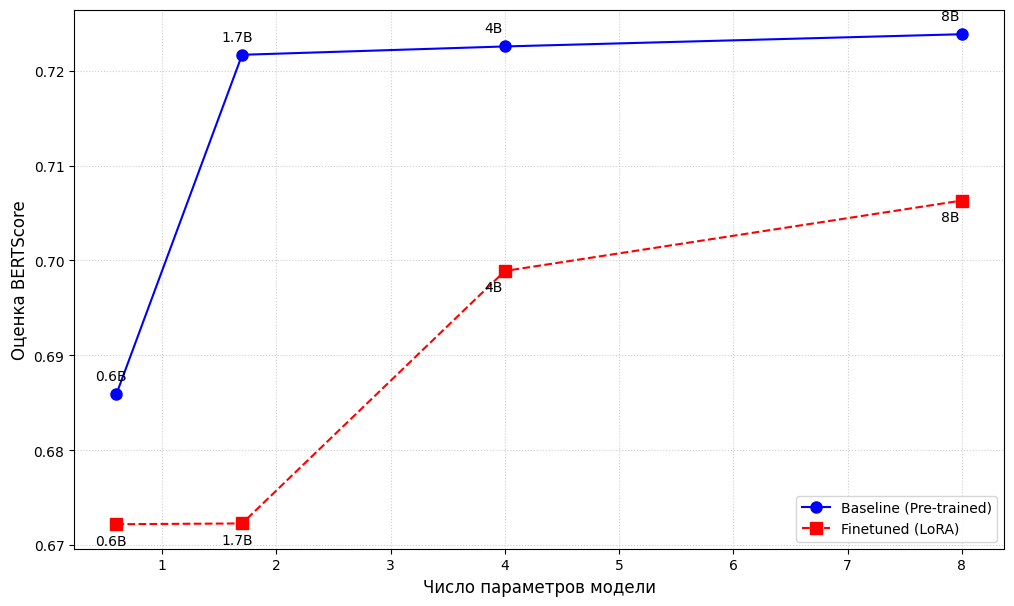

In [ ]:
params_map = {
    "0.6B": 0.6,
    "1.7B": 1.7,
    "4B": 4.0,
    "8B": 8.0
}

model_names = ["0.6B", "1.7B", "4B", "8B"]

bs_baseline = metrics_log[metrics_log['model'].str.contains('Baseline')]['BERTScore'].values
bs_finetuned = metrics_log[metrics_log['model'].str.contains('Finetuned')]['BERTScore'].values
params = [params_map[m] for m in model_names]

plt.figure(figsize=(12, 7))

plt.plot(params, bs_baseline, 'o-', label='Baseline (Pre-trained)', color='blue', markersize=8)
plt.plot(params, bs_finetuned, 's--', label='Finetuned (LoRA)', color='red', markersize=8)

for i, m in enumerate(model_names):
    plt.annotate(m, (params[i], bs_baseline[i]), xytext=(-15, 10), textcoords='offset points')
    plt.annotate(m, (params[i], bs_finetuned[i]), xytext=(-15, -15), textcoords='offset points')

plt.xlabel('Число параметров модели', fontsize=12)
plt.ylabel('Оценка BERTScore', fontsize=12)
plt.legend()
plt.grid(True, linestyle=':', alpha=0.6)
plt.show()

**Выводы:**

1. Дообучение показало неудовлетворительные результаты: после Fine-tuning значения метрик ROUGE и BERTScore снизились по сравнению с базовыми показателями моделей.
Модели демонстрируют катастрофическое забывание, что визуально подтверждается примерами заголовков на тестовых данных (падением способности к качественной генерации на русском языке).

2. Только самая большая модель (8B) оказалась чуть более устойчивой к деградации, продемонстрировав меньший разрыв в качестве относительно младших версий.

3. Вероятно, результат связан с подбором гиперпараметров, однако ограниченные вычислительные ресурсы не позволяют провести серию экспериментов для поиска оптимальных настроек. Но тем не менее, можно заключить, что современные Instruct-модели «из коробки» уже показывают высокие результаты в задачах суммаризации на русском языке. Вероятно, данная задача эффективно решается с помощью качественного промпт-инжиниринга и не требует сложного дообучения.
